In [4]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns  
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import LabelEncoder

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

In [5]:
df = pd.read_csv('/Users/karangautam/Desktop/ppro/amazon/Electronics_extracted.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350000 entries, 0 to 349999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_text  350000 non-null  object 
 1   sentiment    350000 non-null  object 
 2   rating       350000 non-null  float64
dtypes: float64(1), object(2)
memory usage: 8.0+ MB


In [7]:
df['sentiment'].value_counts()

sentiment
Positive    262500
Negative     52500
Neutral      35000
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

27084

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isna().sum()

review_text    0
sentiment      0
rating         0
dtype: int64

In [11]:
df.shape

(322916, 3)

In [12]:
df.sample()

,review_text,sentiment,rating
81284,feels like i'm wearing nothing at all! it is v...,Positive,5.0


In [13]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
Positive    73.944927
Negative    15.802562
Neutral     10.252511
Name: proportion, dtype: float64

In [14]:
df.sample()

,review_text,sentiment,rating
60518,works good for dusting cd lens. works good for...,Positive,5.0


In [15]:
df['rating'].skew()

-1.2325857679737806

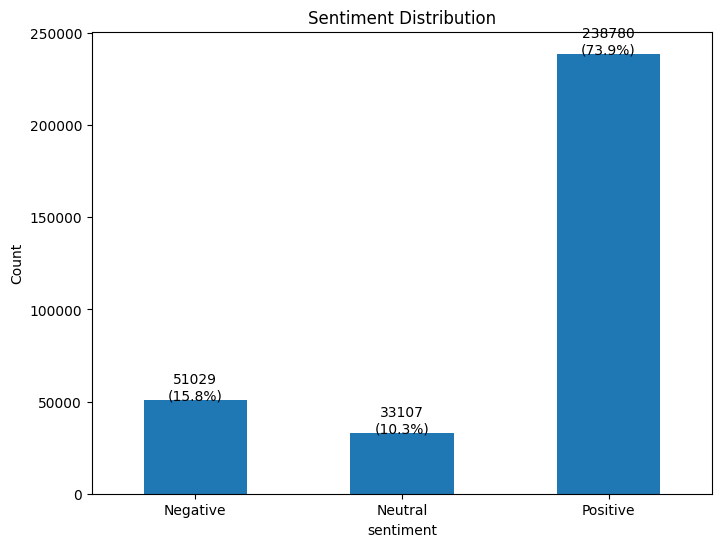

In [16]:
sentiment_counts = df['sentiment'].value_counts().sort_index()
percentages = sentiment_counts / sentiment_counts.sum() * 100

ax = sentiment_counts.plot(kind='bar', figsize=(8, 6))

for i, v in enumerate(sentiment_counts):
    ax.text(i, v, f'{v}\n({percentages[i]:.1f}%)', ha='center')

ax.set_xticklabels(['Negative', 'Neutral', 'Positive'], rotation=0)
ax.set_title('Sentiment Distribution')
ax.set_ylabel('Count')
plt.show()


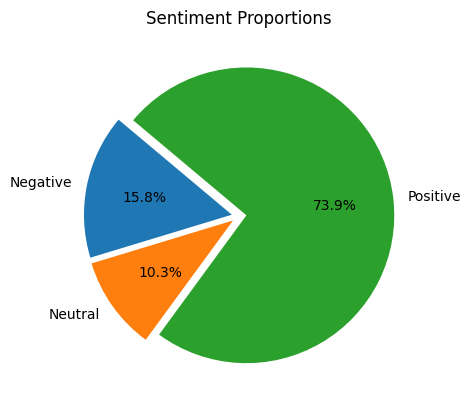

In [17]:
sentiment_counts = df['sentiment'].value_counts().sort_index()
plt.pie(
    sentiment_counts,
    labels=['Negative', 'Neutral', 'Positive'],
    autopct='%1.1f%%',
    startangle=140,
    explode=(0.05, 0.05, 0.05)
)
plt.title('Sentiment Proportions')
plt.show()


In [18]:
per = df['sentiment'].value_counts() * 100 / len(df)

dict = {'Sentiment': ['Negative', 'Neutral', 'Positive'], 'Count': sentiment_counts, 'Percentage': per}
pd.DataFrame(dict)

,Sentiment,Count,Percentage
sentiment,,,
Negative,Negative,51029,15.802562
Neutral,Neutral,33107,10.252511
Positive,Positive,238780,73.944927


In [19]:
df['num_words'] = df['review_text'].apply(lambda x: len(x.split()))
df['num_chars'] = df['review_text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['review_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [20]:
df[df['sentiment'] == 'Negative'][['num_words','num_chars','num_sentences']].describe()

,num_words,num_chars,num_sentences
count,51029.000000,51029.000000,51029.000000
mean,85.827490,98.163280,5.693468
std,93.127211,107.202796,5.336801
min,2.000000,2.000000,1.000000
25%,31.000000,35.000000,2.000000
50%,59.000000,68.000000,4.000000
75%,109.000000,125.000000,7.000000
max,3104.000000,3497.000000,161.000000


In [21]:
df[df['sentiment'] == 'Positive'][['num_words','num_chars','num_sentences']].describe()

,num_words,num_chars,num_sentences
count,238780.000000,238780.000000,238780.000000
mean,71.268251,81.308627,4.852550
std,97.211193,111.619900,5.333384
min,1.000000,1.000000,1.000000
25%,22.000000,25.000000,2.000000
50%,39.000000,45.000000,3.000000
75%,84.000000,95.000000,6.000000
max,3672.000000,4122.000000,204.000000


In [22]:
df[df['sentiment'] == 'Neutral'][['num_words','num_chars','num_sentences']].describe()

,num_words,num_chars,num_sentences
count,33107.000000,33107.000000,33107.000000
mean,91.878636,104.816323,5.596551
std,109.216125,125.691386,6.092161
min,2.000000,2.000000,1.000000
25%,29.000000,33.000000,2.000000
50%,57.000000,65.000000,4.000000
75%,114.000000,130.000000,7.000000
max,3596.000000,4279.000000,234.000000


<Axes: xlabel='num_words', ylabel='Count'>

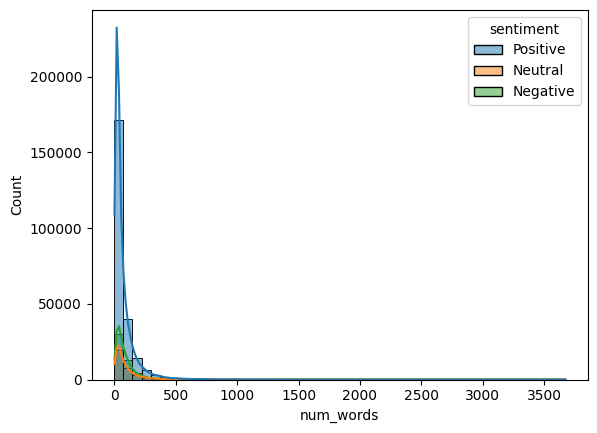

In [23]:
sns.histplot(data=df, x='num_words', hue='sentiment', bins=50, kde=True)

<Axes: xlabel='num_chars', ylabel='Count'>

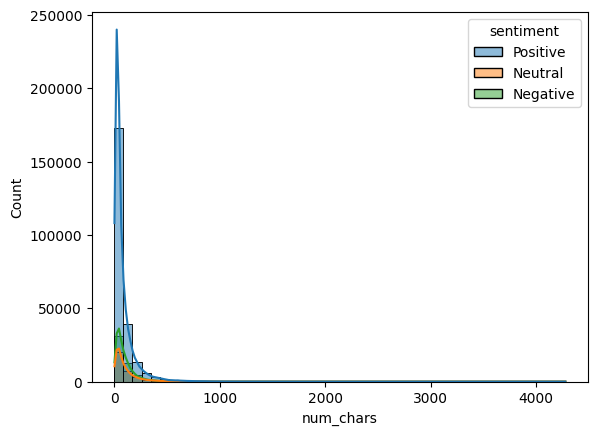

In [24]:
sns.histplot(data=df, x='num_chars', hue='sentiment', bins=50, kde=True)

<Axes: xlabel='num_sentences', ylabel='Count'>

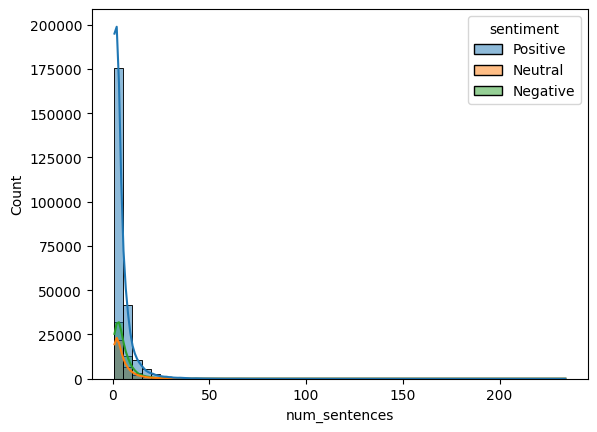

In [25]:
sns.histplot(data=df, x='num_sentences', hue='sentiment', bins=50, kde=True)

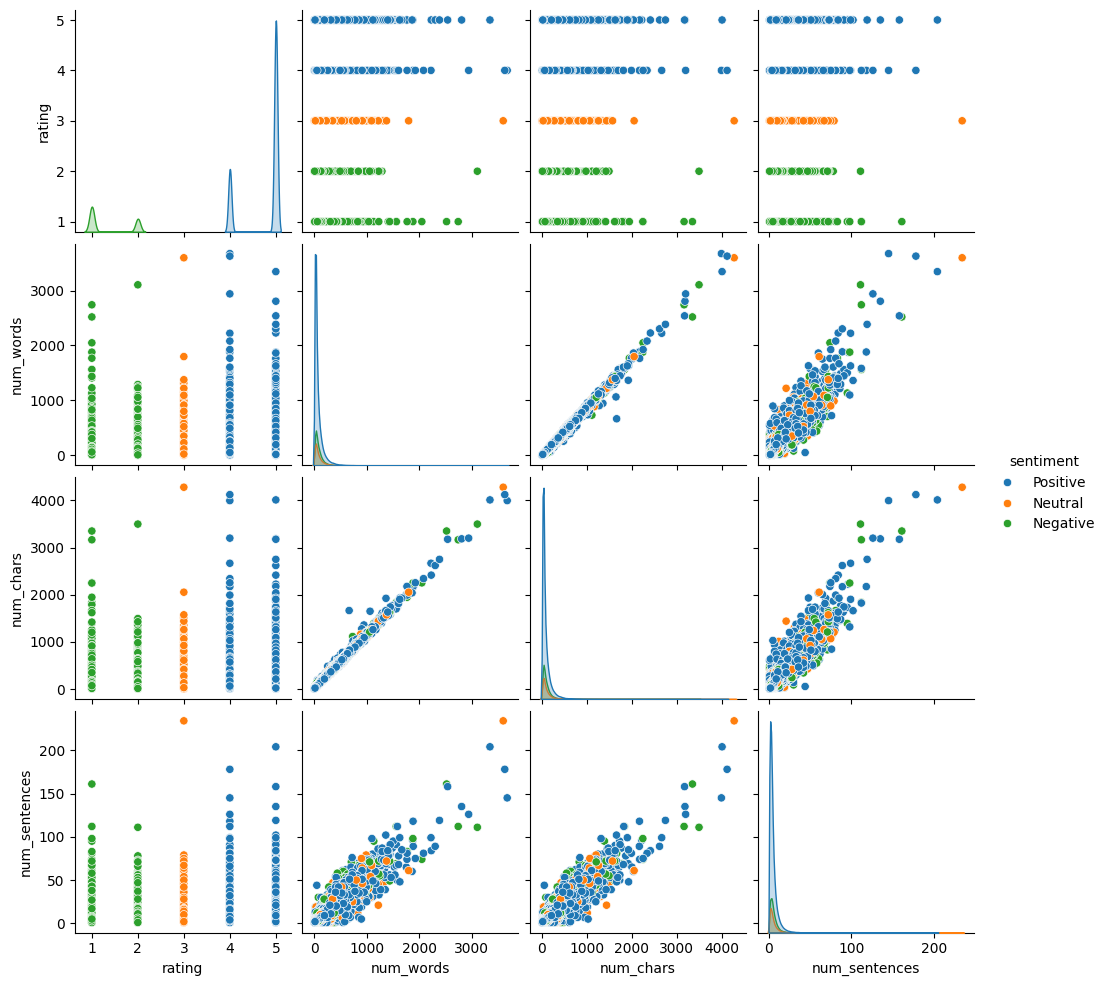

In [26]:
sns.pairplot(df, hue='sentiment')

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'rating'),
  Text(0, 1.5, 'num_words'),
  Text(0, 2.5, 'num_chars'),
  Text(0, 3.5, 'num_sentences')])

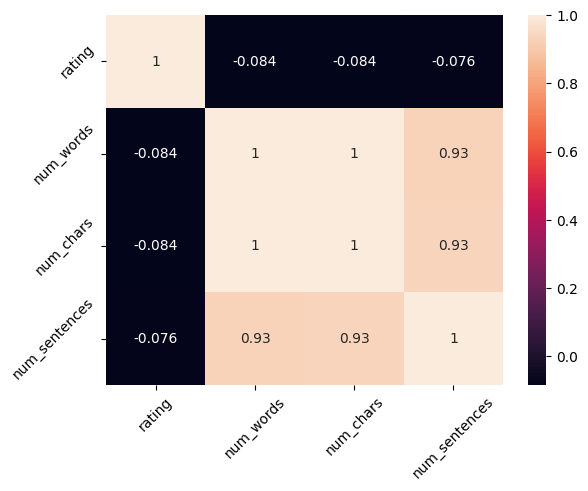

In [27]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.xticks(rotation=45)
plt.yticks(rotation=45)

In [28]:
def transform_text(text):
    text = text.lower()

    words = re.findall(r'\b[a-z]+\b', text)
    
    stop_words = set(stopwords.words('english'))
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [29]:
negative_reviews = df[df['sentiment'] == 'Negative']['review_text'].apply(transform_text)

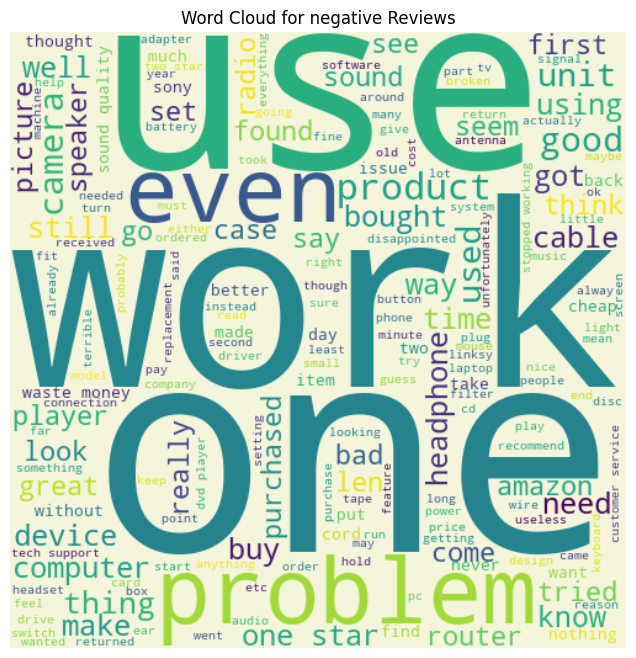

In [30]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='beige')
negative_wc = wc.generate(' '.join(negative_reviews))
plt.figure(figsize=(8, 8))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for negative Reviews')
plt.show()

In [31]:
neutral_reviews = df[df['sentiment'] == 'Neutral']['review_text'].apply(transform_text)

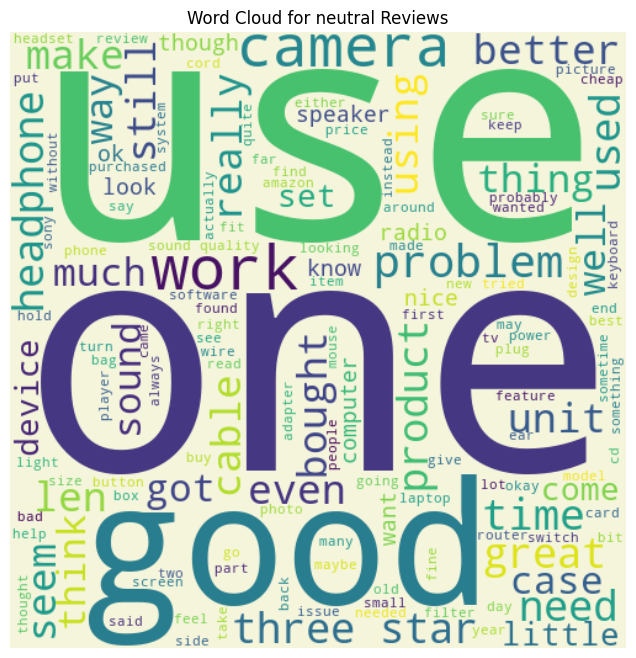

In [32]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='beige')
neutral_wc = wc.generate(' '.join(neutral_reviews))
plt.figure(figsize=(8, 8))
plt.imshow(neutral_wc, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud for neutral Reviews')
plt.show()

In [ ]:
positive_reviews = df[df['sentiment'] == 'Positive']['review_text'].apply(transform_text)

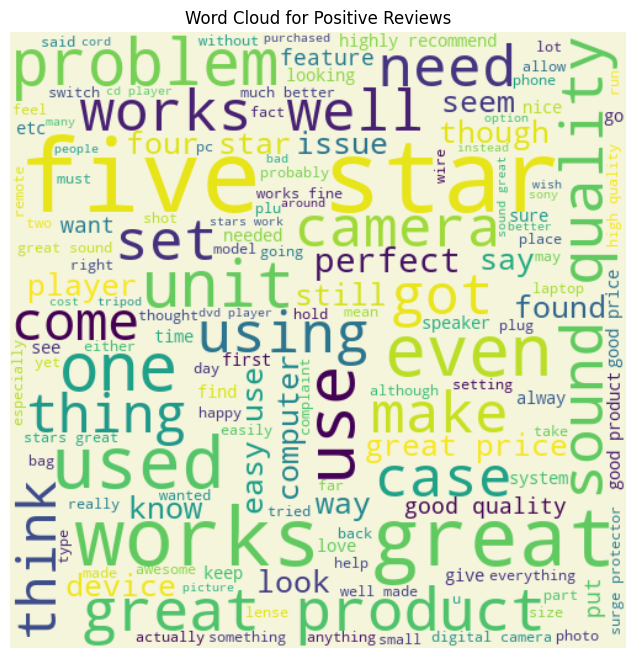

In [ ]:
positive_wc = wc.generate(' '.join(positive_reviews))
plt.figure(figsize=(8, 8))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

In [ ]:
positive_corpus = []

for review in positive_reviews:
    for word in review.split():
        positive_corpus.append(word)
        
positive_word_counts = Counter(positive_corpus)
most_common_positive_words = positive_word_counts.most_common(30)

In [ ]:
most_common_positive_words_df = pd.DataFrame(most_common_positive_words, columns=['Word', 'Count'])

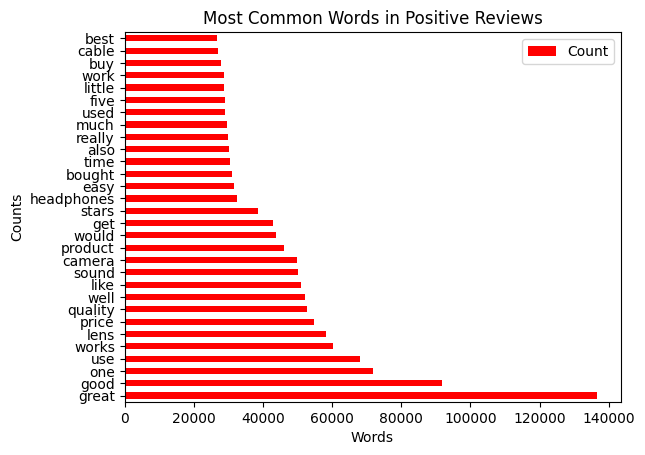

In [ ]:
most_common_positive_words_df.plot.barh(x='Word', y='Count',color='red')

plt.title('Most Common Words in Positive Reviews')
plt.xlabel('Words')
plt.ylabel('Counts')
plt.show()  

In [ ]:
negative_corpus = []

for review in negative_reviews:
    for word in review.split():
        negative_corpus.append(word)
        
negative_word_counts = Counter(negative_corpus)
most_common_negative_words = negative_word_counts.most_common(30)

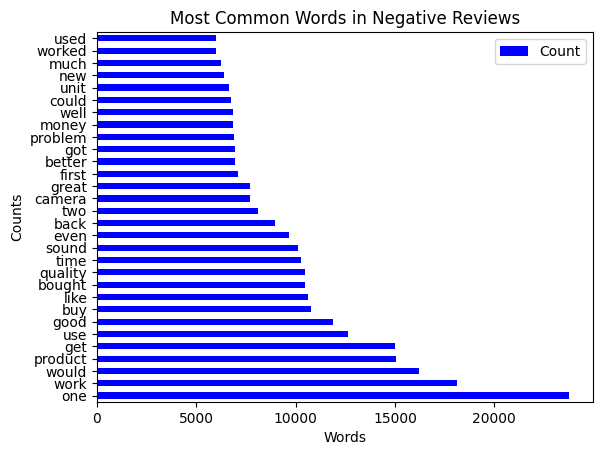

In [ ]:
most_common_negative_words_df = pd.DataFrame(most_common_negative_words, columns=['Word', 'Count'])
most_common_negative_words_df.plot.barh(x='Word', y='Count', color='blue')
plt.title('Most Common Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Counts')
plt.show()

In [ ]:
neutral_corpus = []

for review in neutral_reviews:
    for word in review.split():
        neutral_corpus.append(word)
        
neutral_word_counts = Counter(neutral_corpus)
most_common_neutral_words = neutral_word_counts.most_common(30)

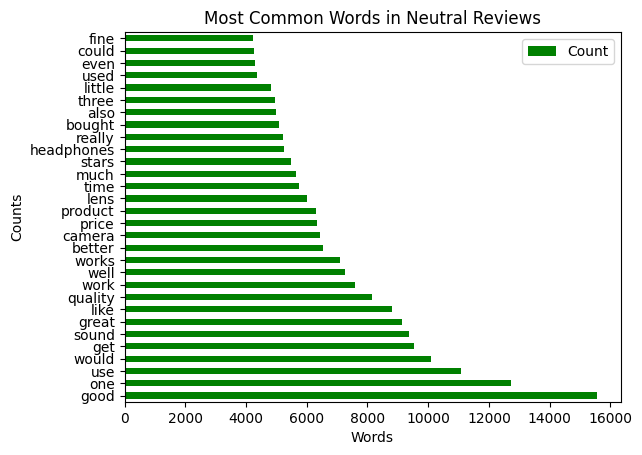

In [ ]:
most_common_neutral_words_df = pd.DataFrame(most_common_neutral_words, columns=['Word', 'Count'])
most_common_neutral_words_df.plot.barh(x='Word', y='Count', color='green')
plt.title('Most Common Words in Neutral Reviews')
plt.xlabel('Words')
plt.ylabel('Counts')
plt.show()

Violin Plots: Text Metrics Distribution by Sentiment

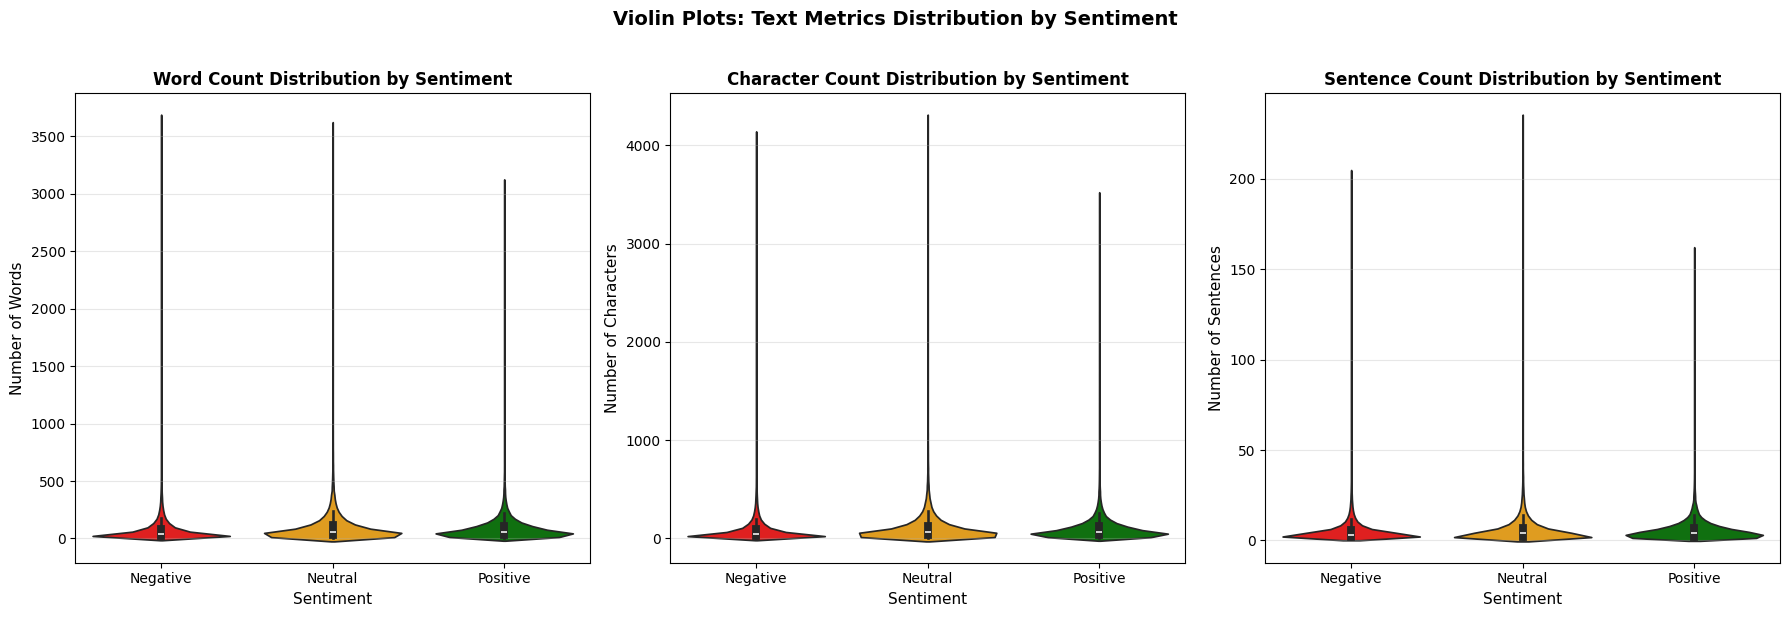

In [ ]:
# Violin Plots: All Three Metrics in One Subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['red', 'orange', 'green']


#  words
sns.violinplot(x='sentiment', y='num_words', data=df, palette=colors, ax=axes[0])
axes[0].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[0].set_title('Word Count Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=11)
axes[0].set_ylabel('Number of Words', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

#  characters
sns.violinplot(x='sentiment', y='num_chars', data=df, palette=colors, ax=axes[1])
axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[1].set_title('Character Count Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=11)
axes[1].set_ylabel('Number of Characters', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

#  sentences
sns.violinplot(x='sentiment', y='num_sentences', data=df, palette=colors, ax=axes[2])
axes[2].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[2].set_title('Sentence Count Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sentiment', fontsize=11)
axes[2].set_ylabel('Number of Sentences', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plots: Text Metrics Distribution by Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Box Plots for All Metrics Side by Side

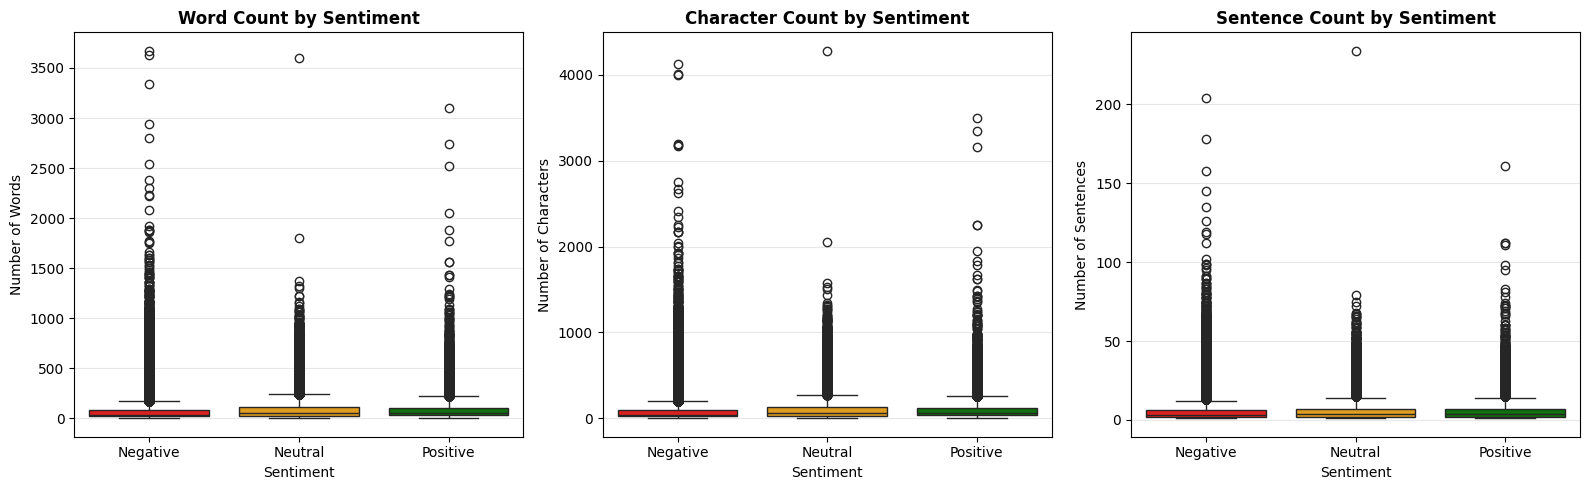

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['red', 'orange', 'green']

# words
sns.boxplot(x='sentiment', y='num_words', data=df, palette=colors, ax=axes[0])
axes[0].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[0].set_title('Word Count by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Words')
axes[0].grid(axis='y', alpha=0.3)

# characters
sns.boxplot(x='sentiment', y='num_chars', data=df, palette=colors, ax=axes[1])
axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[1].set_title('Character Count by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Characters')
axes[1].grid(axis='y', alpha=0.3)

# sentences
sns.boxplot(x='sentiment', y='num_sentences', data=df, palette=colors, ax=axes[2])
axes[2].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[2].set_title('Sentence Count by Sentiment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Number of Sentences')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()